# Advanced Data Analysis and Visualization in Logistics

**Internship Role:** Logistics Data Analyst Intern  
**Organization:** Yuva Intern  
**Prepared by:** Japkirat Kaur  

## Objective

The objective of this project is to simulate and analyze a hypothetical logistics dataset using Python. The analysis focuses on shipment volumes, delivery performance, transportation costs, operational delays, warehouse processing, regional performance, and customer service outcomes.

The project applies exploratory data analysis, descriptive statistics, correlation analysis, and multiple visualization techniques to identify logistics trends, cost drivers, operational bottlenecks, and performance differences. Each visualization is interpreted in a logistics context and used to support evidence-based recommendations.

Because the dataset is hypothetical, the results demonstrate analytical methodology and decision-support techniques rather than the actual performance of a real logistics organization.

## Hypothetical Logistics Dataset Design

A hypothetical shipment-level logistics dataset will be created to support exploratory analysis of operational efficiency, transportation costs, delivery reliability, and customer service performance.

Each row will represent one shipment. The dataset will contain 1,500 simulated shipment records.

### Key Variables

- **Shipment_ID:** Unique identifier for each shipment.
- **Shipment_Date:** Date on which the shipment was processed.
- **Region:** Delivery region used for geographical performance comparison.
- **Transport_Mode:** Transportation method such as Road, Rail, Air, or Sea.
- **Distance_km:** Shipment travel distance in kilometres.
- **Shipment_Volume_kg:** Weight of the shipment in kilograms.
- **Priority:** Standard or Express shipment category.
- **Warehouse_Processing_Hours:** Time spent processing the shipment at the warehouse.
- **Delivery_Time_Hours:** Total delivery duration in hours.
- **Transportation_Cost:** Estimated transportation cost of the shipment.
- **Delay_Hours:** Number of hours by which a shipment was delayed.
- **On_Time_Delivery:** Indicates whether the shipment met its expected delivery requirement.
- **Customer_Rating:** Simulated customer satisfaction rating on a 1–5 scale.

### Simulation Rationale

The simulated data will include realistic analytical relationships rather than completely independent random values. Distance and shipment weight will contribute to transportation cost; transportation mode will influence both delivery time and cost; warehouse processing and operational disruption will contribute to delays; and larger delays will generally be associated with lower customer satisfaction.

These relationships are intentionally simulated for educational analysis. Therefore, subsequent findings demonstrate analytical methods and plausible logistics patterns rather than empirical evidence about a real company.

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

n_shipments = 1500

print("Libraries loaded successfully")
print("Number of shipments:", n_shipments)

Libraries loaded successfully
Number of shipments: 1500


In [65]:
shipment_ids = [f"SHP{str(i).zfill(4)}" for i in range(1, n_shipments + 1)]

shipment_dates = pd.to_datetime("2025-01-01") + pd.to_timedelta(
    np.random.randint(0, 365, n_shipments),
    unit="D"
)

regions = np.random.choice(
    ["North", "South", "East", "West"],
    size=n_shipments,
    p=[0.26, 0.24, 0.25, 0.25]
)

transport_modes = np.random.choice(
    ["Road", "Rail", "Air", "Sea"],
    size=n_shipments,
    p=[0.45, 0.20, 0.20, 0.15]
)

priorities = np.random.choice(
    ["Standard", "Express"],
    size=n_shipments,
    p=[0.70, 0.30]
)

print("Shipment records created:", len(shipment_ids))
print("Simulation period:", shipment_dates.min().date(), "to", shipment_dates.max().date())
print("Regions:", np.unique(regions))
print("Transport modes:", np.unique(transport_modes))
print("Priorities:", np.unique(priorities))

Shipment records created: 1500
Simulation period: 2025-01-01 to 2025-12-31
Regions: ['East' 'North' 'South' 'West']
Transport modes: ['Air' 'Rail' 'Road' 'Sea']
Priorities: ['Express' 'Standard']


In [66]:
distance_km = np.random.randint(50, 3001, n_shipments)

shipment_volume_kg = np.round(
    np.random.lognormal(mean=5.4, sigma=0.7, size=n_shipments),
    2
)

warehouse_processing_hours = np.round(
    np.random.gamma(shape=2.5, scale=1.4, size=n_shipments) + 0.5,
    2
)

print("Distance range:", distance_km.min(), "to", distance_km.max(), "km")
print("Shipment volume range:", shipment_volume_kg.min(), "to", shipment_volume_kg.max(), "kg")
print("Warehouse processing range:", warehouse_processing_hours.min(), "to", warehouse_processing_hours.max(), "hours")

Distance range: 62 to 2997 km
Shipment volume range: 19.55 to 1570.71 kg
Warehouse processing range: 0.56 to 16.11 hours


In [67]:
mode_cost_factor = {
    "Road": 1.00,
    "Rail": 0.75,
    "Air": 2.20,
    "Sea": 0.65
}

transportation_cost = []

for i in range(n_shipments):
    base_cost = 250
    distance_cost = distance_km[i] * 0.55
    weight_cost = shipment_volume_kg[i] * 0.35
    mode_factor = mode_cost_factor[transport_modes[i]]
    random_cost = np.random.normal(0, 80)

    cost = (base_cost + distance_cost + weight_cost) * mode_factor + random_cost
    transportation_cost.append(max(cost, 100))

transportation_cost = np.round(transportation_cost, 2)

print("Minimum transportation cost:", transportation_cost.min())
print("Maximum transportation cost:", transportation_cost.max())
print("Average transportation cost:", np.round(transportation_cost.mean(), 2))

Minimum transportation cost: 100.0
Maximum transportation cost: 4437.94
Average transportation cost: 1346.28


In [68]:
mode_speed = {
    "Road": 55,
    "Rail": 70,
    "Air": 500,
    "Sea": 35
}

delivery_time_hours = []

for i in range(n_shipments):
    travel_time = distance_km[i] / mode_speed[transport_modes[i]]
    processing_time = warehouse_processing_hours[i]
    operational_variation = np.random.gamma(shape=2, scale=1.5)

    total_time = travel_time + processing_time + operational_variation
    delivery_time_hours.append(max(total_time, 1))

delivery_time_hours = np.round(delivery_time_hours, 2)

print("Minimum delivery time:", delivery_time_hours.min(), "hours")
print("Maximum delivery time:", delivery_time_hours.max(), "hours")
print("Average delivery time:", np.round(delivery_time_hours.mean(), 2), "hours")

Minimum delivery time: 2.93 hours
Maximum delivery time: 95.39 hours
Average delivery time: 30.11 hours


In [69]:
delay_hours = []

for i in range(n_shipments):
    warehouse_delay = max(warehouse_processing_hours[i] - 4, 0) * 0.8
    operational_delay = np.random.exponential(scale=2.0)

    if np.random.random() < 0.18:
        disruption_delay = np.random.uniform(4, 15)
    else:
        disruption_delay = 0

    total_delay = warehouse_delay + operational_delay + disruption_delay
    delay_hours.append(total_delay)

delay_hours = np.round(delay_hours, 2)

print("Minimum delay:", delay_hours.min(), "hours")
print("Maximum delay:", delay_hours.max(), "hours")
print("Average delay:", np.round(delay_hours.mean(), 2), "hours")

Minimum delay: 0.0 hours
Maximum delay: 25.93 hours
Average delay: 4.44 hours


In [70]:
on_time_delivery = np.where(
    delay_hours <= 5,
    "Yes",
    "No"
)

on_time_count = np.sum(on_time_delivery == "Yes")
delayed_count = np.sum(on_time_delivery == "No")
on_time_rate = (on_time_count / n_shipments) * 100

print("On-time shipments:", on_time_count)
print("Delayed shipments:", delayed_count)
print("On-time delivery rate:", round(on_time_rate, 2), "%")

On-time shipments: 1036
Delayed shipments: 464
On-time delivery rate: 69.07 %


In [71]:
customer_rating = []

for i in range(n_shipments):
    rating = 4.8 - (delay_hours[i] * 0.12) + np.random.normal(0, 0.35)
    rating = np.clip(rating, 1, 5)
    customer_rating.append(rating)

customer_rating = np.round(customer_rating, 1)

print("Minimum customer rating:", customer_rating.min())
print("Maximum customer rating:", customer_rating.max())
print("Average customer rating:", np.round(customer_rating.mean(), 2))

Minimum customer rating: 1.1
Maximum customer rating: 5.0
Average customer rating: 4.24


In [72]:
df = pd.DataFrame({
    "Shipment_ID": shipment_ids,
    "Shipment_Date": shipment_dates,
    "Region": regions,
    "Transport_Mode": transport_modes,
    "Distance_km": distance_km,
    "Shipment_Volume_kg": shipment_volume_kg,
    "Priority": priorities,
    "Warehouse_Processing_Hours": warehouse_processing_hours,
    "Delivery_Time_Hours": delivery_time_hours,
    "Transportation_Cost": transportation_cost,
    "Delay_Hours": delay_hours,
    "On_Time_Delivery": on_time_delivery,
    "Customer_Rating": customer_rating
})

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1500, 13)


,Shipment_ID,Shipment_Date,Region,Transport_Mode,Distance_km,Shipment_Volume_kg,Priority,Warehouse_Processing_Hours,Delivery_Time_Hours,Transportation_Cost,Delay_Hours,On_Time_Delivery,Customer_Rating
0,SHP0001,2025-04-13,South,Rail,2550,222.22,Standard,2.94,42.01,1250.13,0.20,Yes,4.9
1,SHP0002,2025-12-15,West,Rail,520,471.10,Standard,2.10,15.65,673.23,1.41,Yes,4.3
2,SHP0003,2025-09-28,North,Air,1037,57.52,Standard,3.28,6.40,1954.50,0.44,Yes,4.0
3,SHP0004,2025-04-17,North,Road,2835,131.07,Standard,6.11,59.83,1808.28,3.69,Yes,4.9
4,SHP0005,2025-03-13,North,Road,1984,111.60,Standard,3.01,41.08,1530.69,1.32,Yes,5.0


In [73]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Total missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate Shipment IDs:", df["Shipment_ID"].duplicated().sum())

print("\nData types:")
print(df.dtypes)

Number of rows: 1500
Number of columns: 13
Total missing values: 0
Duplicate rows: 0
Duplicate Shipment IDs: 0

Data types:
Shipment_ID                           object
Shipment_Date                 datetime64[ns]
Region                                object
Transport_Mode                        object
Distance_km                            int64
Shipment_Volume_kg                   float64
Priority                              object
Warehouse_Processing_Hours           float64
Delivery_Time_Hours                  float64
Transportation_Cost                  float64
Delay_Hours                          float64
On_Time_Delivery                      object
Customer_Rating                      float64
dtype: object


In [74]:
df.to_csv("/content/Task_3_Hypothetical_Logistics_Dataset.csv", index=False)

print("Dataset saved successfully.")
print("Saved records:", len(df))
print("Saved variables:", len(df.columns))

Dataset saved successfully.
Saved records: 1500
Saved variables: 13


## Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the overall structure, central tendencies, variability, distributions, and relationships within the simulated logistics dataset. The analysis focuses on key operational metrics including delivery time, transportation cost, shipment volume, warehouse processing time, shipment delays, on-time delivery performance, and customer ratings.

The EDA results will be interpreted in a logistics context to identify potential cost drivers, operational efficiency patterns, performance differences, and possible bottlenecks. Because the dataset is simulated, all findings represent analytical demonstrations rather than measured performance of a real logistics organization.

In [75]:
numeric_columns = [
    "Distance_km",
    "Shipment_Volume_kg",
    "Warehouse_Processing_Hours",
    "Delivery_Time_Hours",
    "Transportation_Cost",
    "Delay_Hours",
    "Customer_Rating"
]

descriptive_stats = df[numeric_columns].describe().T

descriptive_stats["median"] = df[numeric_columns].median()

descriptive_stats = descriptive_stats[
    ["count", "mean", "median", "std", "min", "25%", "50%", "75%", "max"]
]

descriptive_stats.round(2)

,count,mean,median,std,min,25%,50%,75%,max
Distance_km,1500.0,1497.47,1464.50,846.69,62.00,784.50,1464.50,2214.25,2997.00
Shipment_Volume_kg,1500.0,286.54,225.12,219.25,19.55,137.84,225.12,364.70,1570.71
Warehouse_Processing_Hours,1500.0,3.97,3.58,2.14,0.56,2.34,3.58,5.20,16.11
Delivery_Time_Hours,1500.0,30.11,26.16,19.41,2.93,13.01,26.16,43.57,95.39
Transportation_Cost,1500.0,1346.28,1144.08,887.56,100.00,733.26,1144.08,1670.52,4437.94
Delay_Hours,1500.0,4.44,2.76,4.46,0.00,1.26,2.76,5.96,25.93
Customer_Rating,1500.0,4.24,4.40,0.61,1.10,3.90,4.40,4.70,5.00


### Interpretation of Descriptive Statistics

The descriptive statistics provide an initial quantitative view of logistics performance across the 1,500 simulated shipments.

The average delivery time is 30.11 hours, while the median is 26.16 hours. The maximum reaches 95.39 hours, indicating substantial variation in delivery duration. The difference between the mean and median suggests that longer-duration shipments may be pulling the average upward; this pattern will be examined through distribution visualizations.

Average transportation cost is 1,346.28, compared with a median of 1,144.08. Costs range from 100.00 to 4,437.94, showing considerable variation across shipments. Later analysis will examine whether distance, shipment volume, and transportation mode help explain this variation.

Average delay is 4.44 hours, while the median delay is 2.76 hours. The upper quartile is 5.96 hours and the maximum is 25.93 hours. This indicates that although many shipments experience relatively limited delays, a smaller group experiences substantially longer delays that may warrant bottleneck analysis.

Warehouse processing averages 3.97 hours, with values ranging from 0.56 to 16.11 hours. This variable will later be compared with delay performance to assess whether longer warehouse processing is associated with operational delays.

Customer ratings average 4.24 out of 5, with a median of 4.40. Ratings range from 1.10 to 5.00. The relationship between shipment delays and customer ratings will be examined quantitatively through correlation and visualization.

Because these values are generated from a hypothetical dataset, they demonstrate analytical interpretation techniques and should not be treated as real organizational performance benchmarks.

In [76]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Shipments",
        "Average Delivery Time (Hours)",
        "Median Delivery Time (Hours)",
        "Average Transportation Cost",
        "Average Delay (Hours)",
        "On-Time Delivery Rate (%)",
        "Average Warehouse Processing Time (Hours)",
        "Average Customer Rating"
    ],
    "Result": [
        len(df),
        round(df["Delivery_Time_Hours"].mean(), 2),
        round(df["Delivery_Time_Hours"].median(), 2),
        round(df["Transportation_Cost"].mean(), 2),
        round(df["Delay_Hours"].mean(), 2),
        round((df["On_Time_Delivery"] == "Yes").mean() * 100, 2),
        round(df["Warehouse_Processing_Hours"].mean(), 2),
        round(df["Customer_Rating"].mean(), 2)
    ]
})

kpi_summary

,KPI,Result
0,Total Shipments,1500.00
1,Average Delivery Time (Hours),30.11
2,Median Delivery Time (Hours),26.16
3,Average Transportation Cost,1346.28
4,Average Delay (Hours),4.44
5,On-Time Delivery Rate (%),69.07
6,Average Warehouse Processing Time (Hours),3.97
7,Average Customer Rating,4.24


## Distribution Analysis

Distribution analysis is used to understand how key logistics performance measures are spread across shipments and to identify skewness, concentration, variability, and unusually high or low observations.

### Delivery Time Distribution

A histogram is selected for delivery time because delivery time is a continuous quantitative variable. The histogram makes it possible to examine the frequency of different delivery-duration ranges and determine whether most shipments are concentrated around typical delivery times or whether a smaller number of shipments experience substantially longer durations.

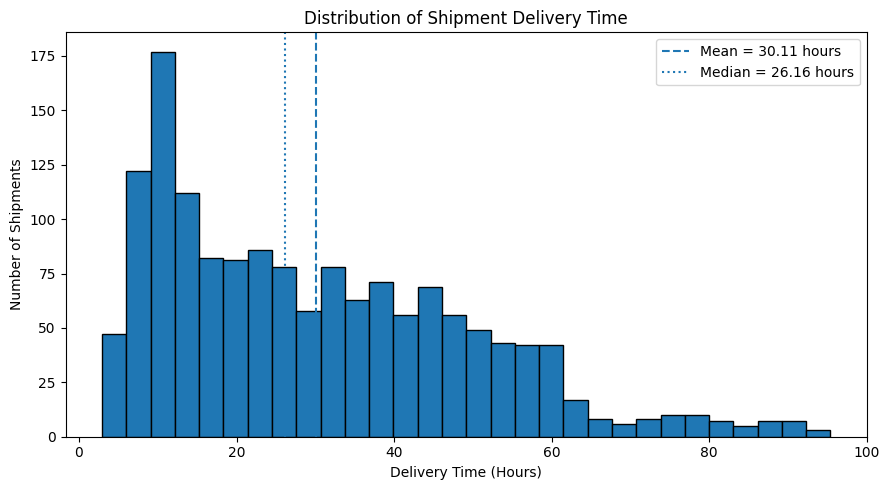

In [77]:
plt.figure(figsize=(9, 5))

plt.hist(
    df["Delivery_Time_Hours"],
    bins=30,
    edgecolor="black"
)

plt.axvline(
    df["Delivery_Time_Hours"].mean(),
    linestyle="--",
    label=f'Mean = {df["Delivery_Time_Hours"].mean():.2f} hours'
)

plt.axvline(
    df["Delivery_Time_Hours"].median(),
    linestyle=":",
    label=f'Median = {df["Delivery_Time_Hours"].median():.2f} hours'
)

plt.title("Distribution of Shipment Delivery Time")
plt.xlabel("Delivery Time (Hours)")
plt.ylabel("Number of Shipments")
plt.legend()
plt.tight_layout()

plt.savefig(
    "/content/Task_3_Delivery_Time_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation: Delivery Time Distribution

The delivery-time histogram shows a positively skewed distribution. The mean delivery time is 30.11 hours, while the median is lower at 26.16 hours. This difference indicates that a smaller number of longer-duration shipments increase the overall average.

Most simulated shipments are concentrated within the lower and middle delivery-time ranges, while the distribution extends to a maximum of 95.39 hours. These high-duration observations should not automatically be classified as errors because delivery time is influenced by simulated factors such as distance, transportation mode, warehouse processing, and operational variation.

From a logistics perspective, the right tail identifies shipments that may require further investigation when assessing operational efficiency and potential bottlenecks. Subsequent analysis will compare delivery performance across transportation modes and other operational characteristics to determine which simulated factors are associated with longer delivery durations.

The histogram is appropriate because it clearly displays the frequency distribution of a continuous performance metric and makes the difference between the mean and median visually interpretable.

### Transportation Cost Distribution

A histogram is selected to examine the distribution of transportation cost because cost is a continuous quantitative logistics variable. This visualization helps identify typical cost ranges, variability, skewness, and the presence of relatively high-cost shipments.

Comparing the mean and median transportation cost also helps determine whether a smaller number of expensive shipments are influencing the overall average. Later analysis will investigate potential cost drivers such as shipment distance, shipment volume, and transportation mode.

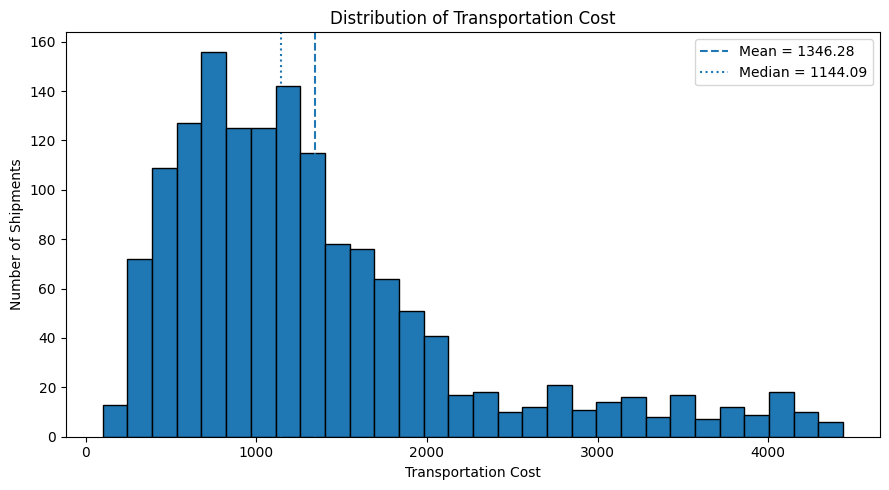

In [78]:
plt.figure(figsize=(9, 5))

plt.hist(
    df["Transportation_Cost"],
    bins=30,
    edgecolor="black"
)

plt.axvline(
    df["Transportation_Cost"].mean(),
    linestyle="--",
    label=f'Mean = {df["Transportation_Cost"].mean():.2f}'
)

plt.axvline(
    df["Transportation_Cost"].median(),
    linestyle=":",
    label=f'Median = {df["Transportation_Cost"].median():.2f}'
)

plt.title("Distribution of Transportation Cost")
plt.xlabel("Transportation Cost")
plt.ylabel("Number of Shipments")
plt.legend()
plt.tight_layout()

plt.savefig(
    "/content/Task_3_Transportation_Cost_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation: Transportation Cost Distribution

The transportation-cost histogram shows a positively skewed distribution. Average transportation cost is approximately 1,346.28, while the median is approximately 1,144.09. The higher mean relative to the median indicates that a smaller number of relatively expensive shipments are increasing the overall average cost.

Most simulated shipments are concentrated in the lower-to-middle cost ranges, while a smaller group extends beyond 4,000. These high-cost observations should not automatically be treated as errors because transportation cost in the simulated dataset is influenced by shipment distance, shipment volume, transportation mode, and operational variation.

From a logistics perspective, the right tail highlights shipments that may contribute disproportionately to transportation expenditure. However, this distribution alone cannot determine the cause of higher costs. Subsequent analysis will therefore examine the relationships between transportation cost and distance, shipment volume, and transport mode.

The histogram is appropriate because it clearly displays the frequency distribution of a continuous cost variable and makes the difference between typical and high-cost shipments visually interpretable.

## Cost Driver Analysis

### Transportation Cost vs Shipment Distance

A scatter plot is selected to examine the relationship between shipment distance and transportation cost because both variables are continuous quantitative measures. Each point represents one simulated shipment, allowing the direction, strength, spread, and possible variation in the relationship to be visually assessed.

A correlation coefficient will also be calculated to quantify the strength of the association. The visualization and correlation will be interpreted together rather than relying on visual appearance alone.

Because the dataset is simulated, any relationship identified represents the designed analytical structure of the hypothetical dataset and should not be interpreted as evidence from a real logistics organization.

Correlation between Distance and Transportation Cost: 0.6


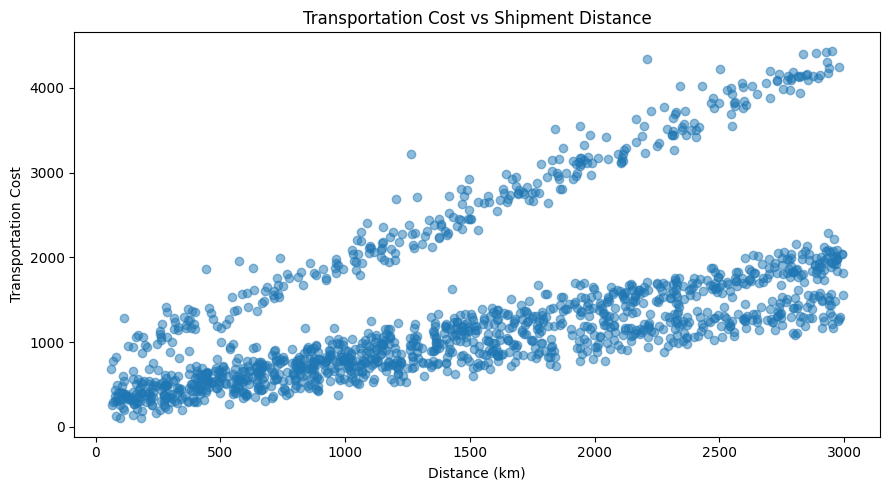

In [79]:
distance_cost_correlation = df["Distance_km"].corr(
    df["Transportation_Cost"]
)

print(
    "Correlation between Distance and Transportation Cost:",
    round(distance_cost_correlation, 3)
)

plt.figure(figsize=(9, 5))

plt.scatter(
    df["Distance_km"],
    df["Transportation_Cost"],
    alpha=0.5
)

plt.title("Transportation Cost vs Shipment Distance")
plt.xlabel("Distance (km)")
plt.ylabel("Transportation Cost")
plt.tight_layout()

plt.savefig(
    "/content/Task_3_Cost_vs_Distance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation: Transportation Cost vs Shipment Distance

The correlation between shipment distance and transportation cost is 0.600, indicating a moderate positive association in the simulated dataset. The scatter plot generally shows higher transportation costs as shipment distance increases.

However, the points do not form a single narrow relationship. Distinct cost patterns are visible across the plot, suggesting that distance alone does not explain transportation-cost variation. In the hypothetical dataset, transportation mode and shipment volume also contribute to cost, which will be examined separately.

From a logistics perspective, the result suggests that longer-distance shipments deserve attention during cost planning, but route distance should not be evaluated in isolation. Cost analysis should also consider transportation mode and shipment characteristics before operational decisions are made.

A scatter plot is appropriate because it displays the relationship between two continuous variables at shipment level, while the correlation coefficient provides a quantitative measure of their association.

Because the data are simulated and the analysis is observational, the correlation should be interpreted as an association within the hypothetical dataset rather than proof that distance alone causes transportation cost.

Correlation between Shipment Volume and Transportation Cost: 0.071


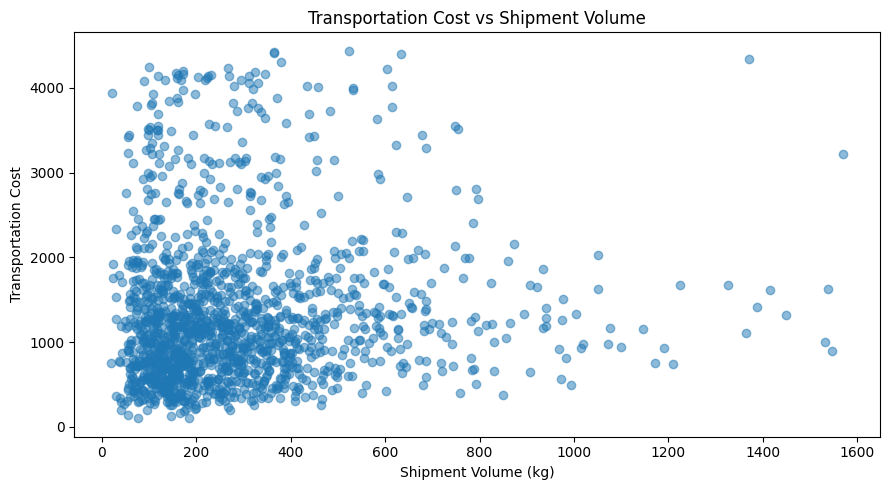

In [80]:
volume_cost_correlation = df["Shipment_Volume_kg"].corr(
    df["Transportation_Cost"]
)

print(
    "Correlation between Shipment Volume and Transportation Cost:",
    round(volume_cost_correlation, 3)
)

plt.figure(figsize=(9, 5))

plt.scatter(
    df["Shipment_Volume_kg"],
    df["Transportation_Cost"],
    alpha=0.5
)

plt.title("Transportation Cost vs Shipment Volume")
plt.xlabel("Shipment Volume (kg)")
plt.ylabel("Transportation Cost")
plt.tight_layout()

plt.savefig(
    "/content/Task_3_Cost_vs_Shipment_Volume.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [81]:
print(round(volume_cost_correlation, 3))

0.071


### Interpretation: Transportation Cost vs Shipment Volume

The Pearson correlation between shipment volume and transportation cost is 0.071, indicating a very weak positive linear association in the simulated dataset. The scatter plot also shows substantial dispersion, with shipments of similar weight occurring across a wide range of transportation costs.

This result suggests that shipment volume alone provides little explanation for transportation-cost variation in this hypothetical dataset. In comparison, shipment distance showed a considerably stronger positive correlation with transportation cost (r = 0.600).

From a logistics perspective, this finding demonstrates why cost decisions should not be based on shipment weight alone. Distance and transportation mode should also be considered when examining cost patterns. The next analysis will compare transportation costs across modes to determine whether mode-related differences help explain the distinct cost patterns observed in the previous visualizations.

The scatter plot is appropriate because it displays shipment-level variation between two continuous variables, while the correlation coefficient quantifies the strength of their linear association.

Because these relationships were generated within a simulated dataset, they illustrate analytical methodology and should not be generalized to real logistics operations without validation using actual operational data.

## Transportation Mode Performance Analysis

Transportation mode is an important operational factor because different modes may have different cost and delivery-time characteristics. The analysis compares Road, Rail, Air, and Sea shipments using shipment volume, average transportation cost, average delivery time, average delay, and on-time delivery rate.

A grouped summary is used first to calculate concrete performance metrics for each transportation mode. Visual comparisons will then be used to identify differences in cost and service performance. These results will help assess potential cost-service trade-offs rather than judging transportation modes on cost alone.

Because transportation mode effects were intentionally incorporated into the hypothetical data-generation process, the results demonstrate how mode-level logistics analysis can be performed rather than representing real-world mode benchmarks.

In [82]:
mode_summary = df.groupby("Transport_Mode").agg(
    Total_Shipments=("Shipment_ID", "count"),
    Average_Cost=("Transportation_Cost", "mean"),
    Average_Delivery_Time=("Delivery_Time_Hours", "mean"),
    Average_Delay=("Delay_Hours", "mean"),
    Average_Customer_Rating=("Customer_Rating", "mean")
).round(2)

mode_on_time = (
    df.assign(On_Time_Flag=(df["On_Time_Delivery"] == "Yes").astype(int))
    .groupby("Transport_Mode")["On_Time_Flag"]
    .mean()
    .mul(100)
    .round(2)
)

mode_summary["On_Time_Rate_Percent"] = mode_on_time

mode_summary

,Total_Shipments,Average_Cost,Average_Delivery_Time,Average_Delay,Average_Customer_Rating,On_Time_Rate_Percent
Transport_Mode,,,,,,
Air,310,2613.68,10.07,4.29,4.29,70.32
Rail,307,898.76,28.96,4.61,4.22,68.73
Road,657,1162.53,33.86,4.52,4.22,67.88
Sea,226,749.92,48.26,4.21,4.26,71.24


In [83]:
mode_summary[["On_Time_Rate_Percent"]]

,On_Time_Rate_Percent
Transport_Mode,
Air,70.32
Rail,68.73
Road,67.88
Sea,71.24


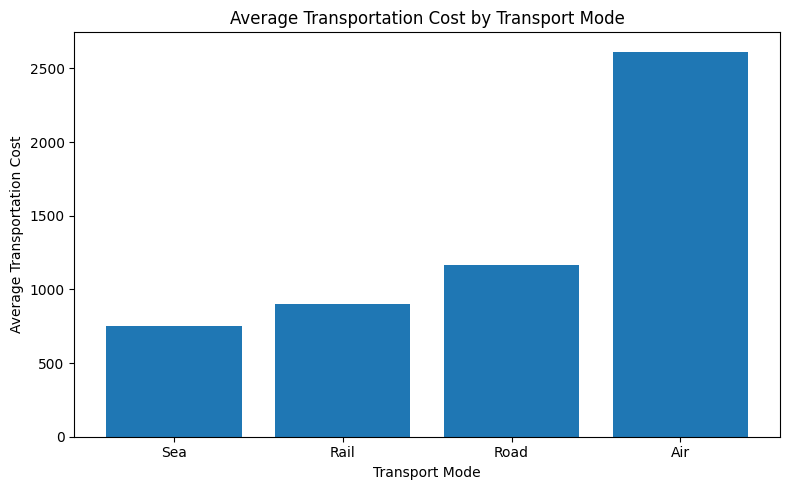

In [84]:
mode_cost = df.groupby("Transport_Mode")["Transportation_Cost"].mean().sort_values()

plt.figure(figsize=(8, 5))

plt.bar(
    mode_cost.index,
    mode_cost.values
)

plt.title("Average Transportation Cost by Transport Mode")
plt.xlabel("Transport Mode")
plt.ylabel("Average Transportation Cost")
plt.tight_layout()

plt.savefig(
    "/content/Task_3_Average_Cost_by_Transport_Mode.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation: Average Transportation Cost by Transport Mode

The bar chart shows substantial differences in average transportation cost across the four simulated transport modes. Air has the highest average cost at 2,613.68, followed by Road at 1,162.53 and Rail at 898.76. Sea has the lowest average transportation cost at 749.92.

These results help explain the distinct cost bands observed in the earlier distance-versus-cost scatter plot. Transportation mode is therefore an important factor to consider alongside shipment distance when interpreting cost variation in this hypothetical dataset.

However, cost should not be evaluated independently of service performance. Air has the shortest average delivery time at 10.07 hours, whereas Sea has the longest at 48.26 hours. This demonstrates a simulated cost-service trade-off: the lowest-cost mode is not necessarily the fastest, while the fastest mode carries substantially higher average cost.

The on-time delivery results also show that absolute delivery duration and schedule reliability are different concepts. Sea records a 71.24% on-time rate despite its longer average delivery duration because on-time status is based on whether the shipment meets its simulated delay threshold rather than how many total hours the journey takes.

A bar chart is appropriate because transportation mode is categorical and average transportation cost is quantitative, allowing mode-level differences to be compared clearly.

For logistics decision-making, mode selection should therefore consider cost, required delivery speed, shipment characteristics, and schedule requirements together rather than selecting a mode using cost alone. Because the dataset is simulated, these values demonstrate analytical decision-support methods and are not real transport-mode benchmarks.

## Operational Bottleneck Analysis

### Warehouse Processing Time vs Shipment Delay

Warehouse processing time is examined as a potential operational bottleneck because extended processing may be associated with shipment delays. A scatter plot is selected because both warehouse processing time and delay hours are continuous quantitative variables.

A Pearson correlation coefficient will be calculated to quantify the strength and direction of the relationship. The visualization and correlation will be interpreted together to determine whether warehouse processing time is meaningfully associated with delay performance in the simulated dataset.

This analysis identifies an association rather than establishing causation. Other simulated operational disruptions also contribute to shipment delays, so warehouse processing should not be treated as the sole explanation for delay performance.

Correlation between Warehouse Processing Time and Delay: 0.221


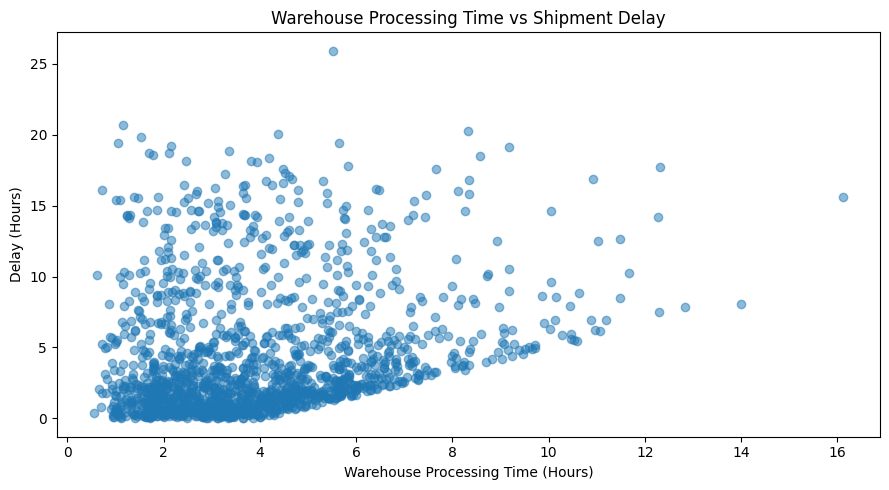

In [85]:
warehouse_delay_correlation = df["Warehouse_Processing_Hours"].corr(
    df["Delay_Hours"]
)

print(
    "Correlation between Warehouse Processing Time and Delay:",
    round(warehouse_delay_correlation, 3)
)

plt.figure(figsize=(9, 5))

plt.scatter(
    df["Warehouse_Processing_Hours"],
    df["Delay_Hours"],
    alpha=0.5
)

plt.title("Warehouse Processing Time vs Shipment Delay")
plt.xlabel("Warehouse Processing Time (Hours)")
plt.ylabel("Delay (Hours)")
plt.tight_layout()

plt.savefig(
    "/content/Task_3_Warehouse_Processing_vs_Delay.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation: Warehouse Processing Time vs Shipment Delay

The Pearson correlation between warehouse processing time and shipment delay is 0.221, indicating a weak positive linear association in the simulated dataset. The scatter plot shows that delays tend to increase somewhat as warehouse processing time rises, but there is substantial variation among individual shipments.

This result suggests that warehouse processing may contribute to delay performance, but it is not the sole factor associated with delays. Some shipments experience relatively high delays even when warehouse processing time is low, which is consistent with the simulated presence of additional operational disruptions.

From a logistics perspective, warehouse processing should therefore be treated as one potential bottleneck rather than the only source of delay. A practical response would be to monitor shipments with unusually long warehouse processing times, investigate process stages responsible for extended handling, and separately classify non-warehouse disruptions before deciding where improvement efforts should be concentrated.

The scatter plot is appropriate because it displays shipment-level variation between two continuous operational measures, while the correlation coefficient quantifies the strength of their linear association.

The correlation does not establish that longer warehouse processing causes shipment delays. Furthermore, because the dataset is hypothetical, the result demonstrates a bottleneck-analysis methodology that would require validation using real operational data before implementation.

## Customer Service Impact Analysis

### Shipment Delay vs Customer Rating

Shipment delay is compared with customer rating to examine whether poorer delivery reliability is associated with lower simulated customer satisfaction.

A scatter plot is selected because both delay hours and customer rating are quantitative variables. A Pearson correlation coefficient will also be calculated to measure the direction and strength of their linear association.

This analysis connects operational logistics performance with a customer-oriented outcome. However, the relationship was intentionally incorporated into the hypothetical data-generation process, so the result demonstrates how service-impact analysis can be performed rather than providing evidence about actual customer behaviour.

Correlation between Shipment Delay and Customer Rating: -0.847


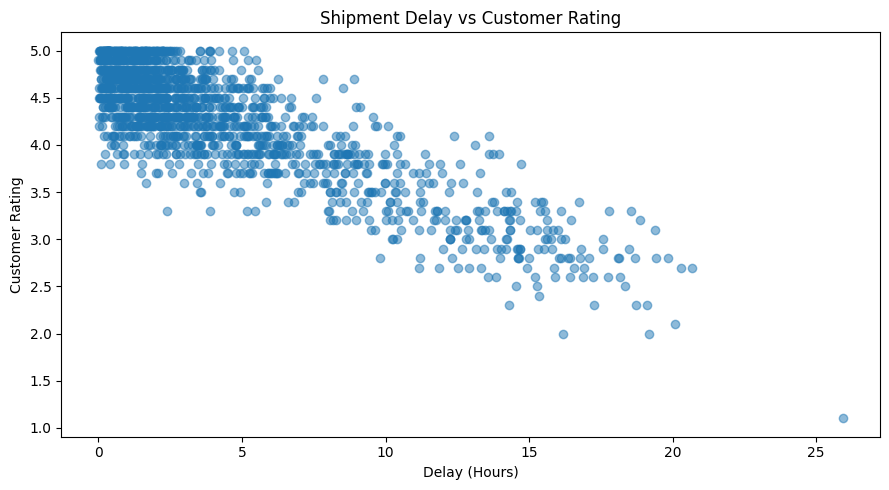

In [86]:
delay_rating_correlation = df["Delay_Hours"].corr(
    df["Customer_Rating"]
)

print(
    "Correlation between Shipment Delay and Customer Rating:",
    round(delay_rating_correlation, 3)
)

plt.figure(figsize=(9, 5))

plt.scatter(
    df["Delay_Hours"],
    df["Customer_Rating"],
    alpha=0.5
)

plt.title("Shipment Delay vs Customer Rating")
plt.xlabel("Delay (Hours)")
plt.ylabel("Customer Rating")
plt.tight_layout()

plt.savefig(
    "/content/Task_3_Delay_vs_Customer_Rating.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [87]:
print(round(delay_rating_correlation, 3))

-0.847


### Interpretation: Shipment Delay vs Customer Rating

The Pearson correlation between shipment delay and customer rating is -0.847, indicating a strong negative linear association in the simulated dataset. The scatter plot clearly shows that customer ratings generally decrease as shipment delays become longer.

This relationship is substantially stronger than several other associations identified in the analysis. For example, warehouse processing time and delay showed only a weak positive correlation (r = 0.221). The result therefore highlights delivery reliability as an important customer-service dimension within the hypothetical logistics scenario.

From a logistics-management perspective, reducing severe delays may support both operational performance and customer-service outcomes. A practical approach would be to identify shipments at risk of extended delay, investigate recurring delay sources, prioritize exception management, and provide proactive customer communication when delays cannot be avoided.

The scatter plot is appropriate because it displays the relationship between shipment-level delay and customer rating, while the Pearson correlation coefficient quantifies the strength and direction of their linear association.

The relationship should not be interpreted as independent evidence that delays cause customer dissatisfaction because customer rating was intentionally designed to decline with increasing delay during data simulation. In a real logistics environment, this relationship would need to be tested using actual customer and shipment records while considering other factors that may influence satisfaction.

## Correlation Analysis of Logistics Variables

Correlation analysis is used to examine the direction and strength of linear relationships among the major quantitative logistics variables. This provides a broader view of how distance, shipment volume, warehouse processing time, delivery time, transportation cost, delay, and customer rating move together within the simulated dataset.

Pearson correlation coefficients range from -1 to +1. Values closer to +1 indicate stronger positive linear associations, values closer to -1 indicate stronger negative linear associations, and values near zero indicate weak linear relationships.

Correlation is used here as an exploratory analytical tool and does not establish causation. In addition, several relationships were intentionally incorporated into the hypothetical data-generation process. Therefore, the correlation results demonstrate analytical techniques rather than independently discovered real-world logistics relationships.

In [88]:
correlation_columns = [
    "Distance_km",
    "Shipment_Volume_kg",
    "Warehouse_Processing_Hours",
    "Delivery_Time_Hours",
    "Transportation_Cost",
    "Delay_Hours",
    "Customer_Rating"
]

correlation_matrix = df[correlation_columns].corr()

correlation_matrix.round(3)

,Distance_km,Shipment_Volume_kg,Warehouse_Processing_Hours,Delivery_Time_Hours,Transportation_Cost,Delay_Hours,Customer_Rating
Distance_km,1.000,0.011,-0.007,0.679,0.600,-0.036,0.033
Shipment_Volume_kg,0.011,1.000,-0.030,0.035,0.071,0.011,-0.021
Warehouse_Processing_Hours,-0.007,-0.030,1.000,0.087,-0.005,0.221,-0.198
Delivery_Time_Hours,0.679,0.035,0.087,1.000,-0.086,-0.014,-0.013
Transportation_Cost,0.600,0.071,-0.005,-0.086,1.000,-0.024,0.048
Delay_Hours,-0.036,0.011,0.221,-0.014,-0.024,1.000,-0.847
Customer_Rating,0.033,-0.021,-0.198,-0.013,0.048,-0.847,1.000


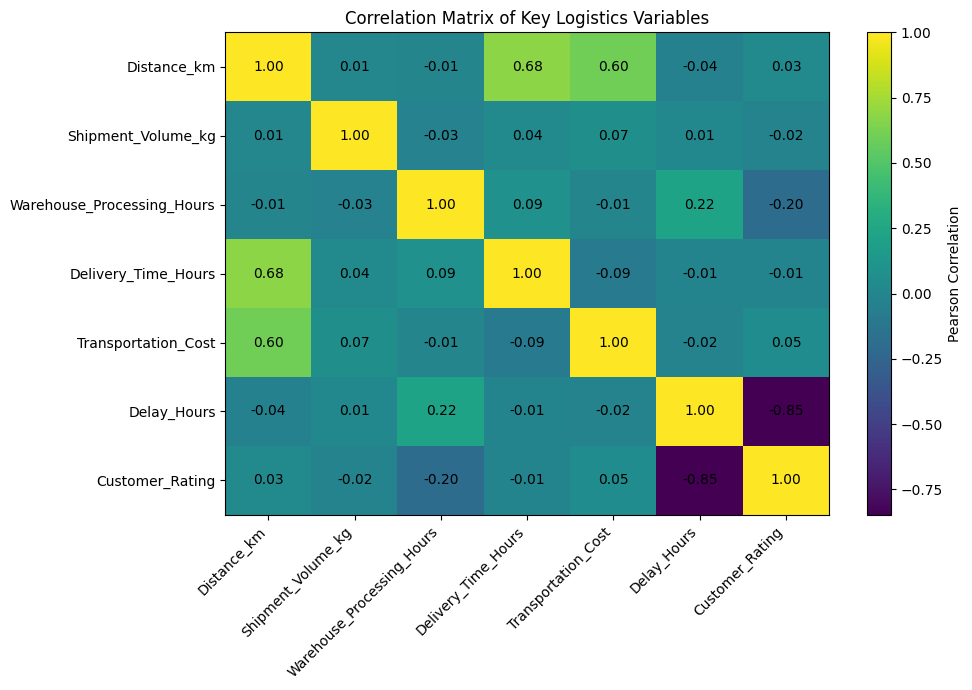

In [89]:
plt.figure(figsize=(10, 7))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar(label="Pearson Correlation")

plt.xticks(
    range(len(correlation_columns)),
    correlation_columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_columns)),
    correlation_columns
)

for i in range(len(correlation_columns)):
    for j in range(len(correlation_columns)):
        plt.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation Matrix of Key Logistics Variables")
plt.tight_layout()

plt.savefig(
    "/content/Task_3_Logistics_Correlation_Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation: Correlation Matrix

The correlation matrix provides an integrated view of the linear relationships among the main quantitative logistics variables in the simulated dataset.

One of the strongest positive relationships is between shipment distance and delivery time (r = 0.679), indicating that longer-distance shipments generally require more delivery time. Shipment distance also has a moderate positive relationship with transportation cost (r = 0.600), supporting the earlier cost-driver analysis.

Warehouse processing time has a weak positive association with shipment delay (r = 0.221). This suggests that longer warehouse processing may contribute to delay performance, but it does not explain most of the variation in delays.

The strongest negative relationship is between shipment delay and customer rating (r = -0.847). Within the simulated dataset, longer delays are strongly associated with lower customer ratings. Warehouse processing time also has a weak negative association with customer rating (approximately r = -0.20), which may partly reflect its relationship with delay.

Shipment volume shows only weak linear relationships with the other major performance variables, including transportation cost. This demonstrates that variables that appear operationally important do not necessarily have strong individual statistical relationships in every dataset.

The correlation heatmap is useful because it allows multiple relationships to be compared simultaneously and highlights which variable pairs deserve deeper investigation. However, correlation does not establish causation, and several relationships were intentionally incorporated during data simulation. Therefore, these coefficients demonstrate analytical methodology rather than independently discovered real-world logistics effects.

## Delivery Reliability Analysis

### On-Time vs Delayed Shipments

On-time delivery is a key logistics performance indicator because it measures schedule reliability rather than simply measuring total delivery duration. In this simulated project, a shipment is classified as on time when its delay is 5 hours or less.

A bar chart will be used to compare the number of on-time and delayed shipments because delivery status is a categorical variable. The visualization will complement the overall on-time delivery rate and make the balance between successful and delayed shipments immediately visible.

The 5-hour threshold is a project-specific simulation rule and should not be interpreted as a universal logistics industry standard. In a real organization, on-time performance should be calculated using contractual or operational service-level targets.

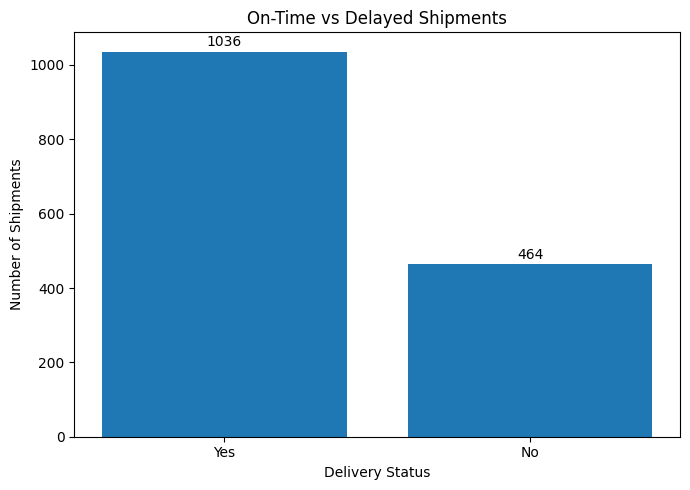

On-Time Delivery Rate: 69.07 %
Delayed Shipment Rate: 30.93 %


In [90]:
delivery_status_counts = df["On_Time_Delivery"].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(
    delivery_status_counts.index,
    delivery_status_counts.values
)

plt.title("On-Time vs Delayed Shipments")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Shipments")

for i, value in enumerate(delivery_status_counts.values):
    plt.text(
        i,
        value + 15,
        str(value),
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    "/content/Task_3_On_Time_vs_Delayed_Shipments.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("On-Time Delivery Rate:", round((df["On_Time_Delivery"] == "Yes").mean() * 100, 2), "%")
print("Delayed Shipment Rate:", round((df["On_Time_Delivery"] == "No").mean() * 100, 2), "%")

### Interpretation: On-Time vs Delayed Shipments

Out of 1,500 simulated shipments, 1,036 shipments are classified as on time and 464 are classified as delayed. This corresponds to an on-time delivery rate of 69.07% and a delayed shipment rate of 30.93%.

The bar chart makes the difference between the two delivery-status groups immediately visible. Although the majority of simulated shipments meet the project-defined on-time requirement, nearly one-third fall outside it. Within this hypothetical scenario, this delayed group represents an important area for further operational investigation.

The earlier bottleneck analysis showed only a weak positive association between warehouse processing time and delay (r = 0.221). Therefore, improvement efforts should not focus exclusively on warehouse processing. A more appropriate approach would be to segment delayed shipments by delay source, transportation mode, processing time, distance, and other operational exceptions to identify where intervention could be most effective.

The bar chart is appropriate because delivery status is categorical and the objective is to compare the number of shipments in each category clearly.

The 69.07% on-time rate is based on the project-specific simulated rule that shipments with delays of 5 hours or less are considered on time. It is not an industry benchmark. A real logistics organization should calculate this KPI using its contractual service-level agreements and promised delivery schedules.

## Monthly Logistics Trend Analysis

### Monthly Shipment Volume

A monthly trend analysis is used to examine how shipment activity changes across the simulated year. Shipment records are grouped by month and counted to measure monthly shipment volume.

A line chart is selected because the observations follow a chronological sequence. It allows month-to-month changes, peaks, declines, and overall patterns in shipment activity to be identified more clearly than a categorical comparison.

Because shipment dates were generated hypothetically across 2025, any monthly fluctuations represent simulated variation rather than actual seasonality or demand patterns. Therefore, peaks should not be attributed to holidays, promotions, weather, or other real-world events without supporting operational data.

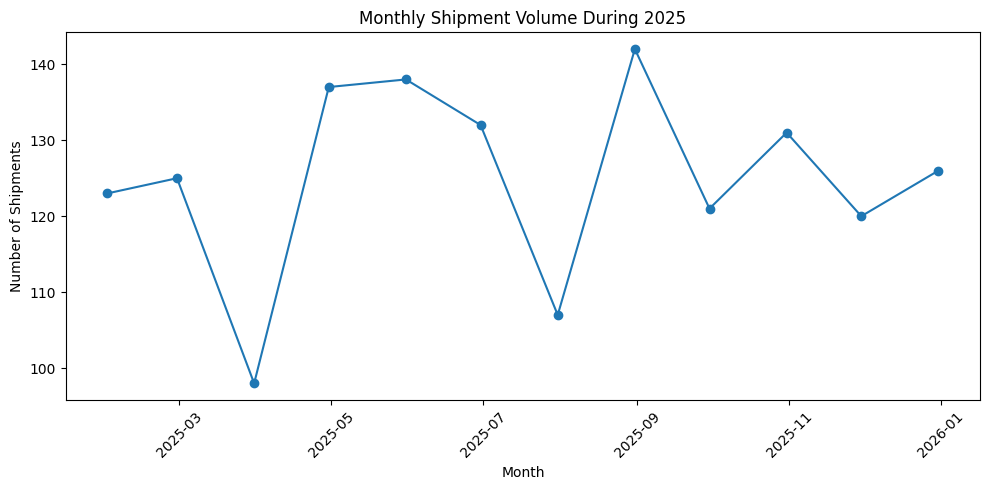

Highest-volume month: August - 142 shipments
Lowest-volume month: March - 98 shipments


In [91]:
monthly_shipments = (
    df.set_index("Shipment_Date")
    .resample("ME")
    .size()
)

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_shipments.index,
    monthly_shipments.values,
    marker="o"
)

plt.title("Monthly Shipment Volume During 2025")
plt.xlabel("Month")
plt.ylabel("Number of Shipments")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "/content/Task_3_Monthly_Shipment_Volume.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Highest-volume month:", monthly_shipments.idxmax().strftime("%B"), "-", monthly_shipments.max(), "shipments")
print("Lowest-volume month:", monthly_shipments.idxmin().strftime("%B"), "-", monthly_shipments.min(), "shipments")

In [92]:
print("Highest-volume month:", monthly_shipments.idxmax().strftime("%B"), "-", monthly_shipments.max(), "shipments")
print("Lowest-volume month:", monthly_shipments.idxmin().strftime("%B"), "-", monthly_shipments.min(), "shipments")

Highest-volume month: August - 142 shipments
Lowest-volume month: March - 98 shipments


### Interpretation: Monthly Shipment Volume

Monthly shipment activity varies across the simulated 2025 period. August records the highest shipment volume with 142 shipments, while March records the lowest volume with 98 shipments. The difference between these months is 44 shipments.

The line chart shows several month-to-month increases and decreases rather than a consistent upward or downward trend across the year. This variation demonstrates how time-based analysis can help logistics teams identify periods of relatively higher and lower operational workload.

From a logistics-management perspective, monthly shipment-volume monitoring can support capacity planning for warehouse labour, transportation resources, vehicle availability, and shipment scheduling. Periods of higher expected volume may require additional operational capacity, while lower-volume periods may provide opportunities for maintenance, training, or process improvement activities.

However, no causal explanation should be assigned to the August peak or March low from this dataset alone. Shipment dates were simulated, and the dataset contains no information about holidays, promotions, weather, customer demand, or other external factors that could explain monthly variation.

A line chart is appropriate because shipment volume is being compared sequentially across time, making month-to-month changes and peaks easier to identify.

## Regional Performance Analysis

Regional analysis is used to compare logistics performance across the North, South, East, and West regions in the simulated dataset. The comparison focuses on shipment volume, average delivery time, average transportation cost, average delay, and on-time delivery rate.

A grouped performance table will first be calculated to provide concrete regional metrics. This helps identify whether any simulated region shows noticeably different operational patterns and prevents conclusions from being based only on overall averages.

Because region assignments were generated hypothetically, regional differences should be interpreted as simulated analytical patterns rather than evidence about real geographic logistics performance.

In [93]:
regional_summary = df.groupby("Region").agg(
    Total_Shipments=("Shipment_ID", "count"),
    Average_Delivery_Time=("Delivery_Time_Hours", "mean"),
    Average_Transportation_Cost=("Transportation_Cost", "mean"),
    Average_Delay=("Delay_Hours", "mean"),
    Average_Customer_Rating=("Customer_Rating", "mean")
).round(2)

regional_on_time = (
    df.assign(On_Time_Flag=(df["On_Time_Delivery"] == "Yes").astype(int))
    .groupby("Region")["On_Time_Flag"]
    .mean()
    .mul(100)
    .round(2)
)

regional_summary["On_Time_Rate_Percent"] = regional_on_time

regional_summary

,Total_Shipments,Average_Delivery_Time,Average_Transportation_Cost,Average_Delay,Average_Customer_Rating,On_Time_Rate_Percent
Region,,,,,,
East,384,30.48,1353.61,4.58,4.22,65.62
North,409,29.07,1333.89,4.32,4.25,72.37
South,338,29.61,1326.75,4.40,4.24,69.23
West,369,31.33,1370.29,4.48,4.25,68.83


### Interpretation: Regional Logistics Performance

The regional comparison shows moderate variation in logistics performance across the four simulated regions.

North handles the largest shipment volume with 409 shipments and records the highest on-time delivery rate at 72.37%. Its average delivery time is 29.07 hours and average delay is 4.32 hours.

East handles 384 shipments and records the lowest on-time delivery rate at 65.62%. It also has the highest average delay at 4.58 hours, suggesting that this simulated region would merit further investigation if the pattern appeared in real operational data.

West records the highest average delivery time at 31.33 hours and the highest average transportation cost at 1,370.29. South records an on-time rate of 69.23%, while West records 68.83%.

From a logistics-management perspective, regional KPI monitoring can help identify areas requiring deeper operational review. A practical next step would be to examine transportation-mode mix, shipment distance, warehouse processing, and delay sources within lower-performing regions before implementing corrective action.

The regional differences should not be interpreted as evidence that geographic location caused the observed performance variation. Region assignments were simulated, and no real infrastructure, traffic, weather, demand, or facility-level information is available. Therefore, these results demonstrate regional performance analysis rather than real geographic performance differences.

## Key Analytical Findings

The exploratory analysis of 1,500 simulated logistics shipments produced the following key findings:

1. **Overall delivery performance:** The average delivery time is 30.11 hours, with a median of 26.16 hours. The distribution is positively skewed, indicating that a smaller number of long-duration shipments increase the overall average.

2. **Delivery reliability:** 1,036 shipments are classified as on time and 464 as delayed, producing an on-time delivery rate of 69.07% under the project-specific 5-hour delay threshold.

3. **Transportation-cost variation:** Average transportation cost is 1,346.28, while the median is approximately 1,144.09. The cost distribution is positively skewed, with a smaller group of high-cost shipments.

4. **Distance as a cost-related factor:** Shipment distance has a moderate positive correlation with transportation cost (r = 0.600) and a stronger positive association with delivery time (r = 0.679).

5. **Shipment volume and cost:** Shipment volume has only a very weak positive correlation with transportation cost (r = 0.071), indicating that shipment weight alone provides little explanation for cost variation in this simulated dataset.

6. **Transport-mode trade-off:** Air has the highest average transportation cost at 2,613.68 but the shortest average delivery time at 10.07 hours. Sea has the lowest average cost at 749.92 but the longest average delivery time at 48.26 hours. This demonstrates a clear simulated cost-service trade-off.

7. **Warehouse bottleneck evidence:** Warehouse processing time has a weak positive correlation with shipment delay (r = 0.221). It may contribute to delays, but the evidence indicates that other operational factors are also important.

8. **Customer-service relationship:** Shipment delay has a strong negative correlation with customer rating (r = -0.847). Within the simulated design, longer delays are associated with lower customer ratings.

9. **Monthly workload variation:** August has the highest simulated shipment volume with 142 shipments, while March has the lowest with 98 shipments. No real-world seasonal explanation can be inferred because shipment dates were simulated.

10. **Regional variation:** North records the highest on-time delivery rate at 72.37%, while East records the lowest at 65.62%. These differences require deeper operational investigation rather than attribution to geography because region assignments are hypothetical.

Overall, the analysis demonstrates that logistics performance should be evaluated through multiple dimensions—including cost, speed, reliability, operational processing, and customer outcomes—rather than relying on a single performance measure.

## Actionable Logistics Recommendations

Based on the exploratory analysis of the simulated logistics dataset, the following actions are recommended:

### 1. Strengthen Delay and Exception Management
The simulated on-time delivery rate is 69.07%, while 30.93% of shipments fall outside the project-defined on-time threshold. Delayed shipments should be segmented by transportation mode, warehouse processing time, distance, and operational disruption type. This would help distinguish recurring bottlenecks from isolated exceptions and allow corrective actions to target specific delay sources.

### 2. Monitor Warehouse Processing Without Treating It as the Sole Bottleneck
Warehouse processing time has a weak positive correlation with shipment delay (r = 0.221). Therefore, warehouse processing should be monitored using processing-time thresholds and exception alerts, but improvement efforts should also investigate other operational delay sources. Focusing only on warehouse operations would not be supported by the observed relationship.

### 3. Use Transportation Mode According to Cost-Service Requirements
Air has the shortest average delivery time at 10.07 hours but the highest average transportation cost at 2,613.68. Sea has the lowest average cost at 749.92 but the longest average delivery time at 48.26 hours. Mode selection should therefore consider shipment urgency, service requirements, cost constraints, and schedule reliability together rather than selecting the cheapest or fastest mode automatically.

### 4. Include Distance in Transportation Cost Planning
Shipment distance has a moderate positive association with transportation cost (r = 0.600). Distance should therefore be incorporated into transportation budgeting, route evaluation, and cost forecasting. However, transportation mode and other shipment characteristics should also be considered because distance alone does not explain all cost variation.

### 5. Do Not Use Shipment Weight Alone for Cost Decisions
Shipment volume has only a very weak relationship with transportation cost (r = 0.071) in the simulated dataset. Cost-estimation approaches should therefore avoid relying on shipment weight as a standalone predictor and should evaluate multiple operational variables together.

### 6. Prioritize Management of Severe Delays
Shipment delay has a strong negative association with customer rating (r = -0.847) within the simulated design. Logistics teams should identify shipments at risk of extended delay, prioritize exception handling, and communicate proactively with customers when service disruption cannot be avoided. In real operations, the relationship should be validated using actual customer-feedback data.

### 7. Use Monthly Volume Monitoring for Capacity Planning
Monthly shipment volume ranges from 98 shipments in March to 142 in August. Regular workload monitoring can support warehouse staffing, vehicle planning, scheduling, and resource allocation. Because the dataset is simulated, these particular months should not be treated as evidence of real seasonal demand.

### 8. Investigate Regional KPI Differences Before Taking Corrective Action
The simulated on-time delivery rate ranges from 65.62% in East to 72.37% in North. Rather than attributing this difference directly to geography, further analysis should compare mode mix, distance, warehouse processing, and delay sources within each region before operational changes are implemented.

### Implementation Principle

These recommendations demonstrate how analytical findings can be translated into logistics actions. Because the dataset is hypothetical, the recommendations should be treated as decision-support examples rather than immediate real-world prescriptions. Before implementation in an actual logistics organization, the analysis should be repeated using real operational data, contractual service-level definitions, validated delay causes, and relevant business constraints.

## Feasibility and Limitations of the Analysis

The analysis provides a practical demonstration of how Python-based exploratory data analysis and visualization can support logistics decision-making. However, the findings must be interpreted within the limitations of the hypothetical dataset.

### Feasibility

The analytical workflow is technically feasible for a real logistics environment because the methods used—including descriptive statistics, KPI calculation, grouped performance analysis, Pearson correlation, histograms, scatter plots, bar charts, and time-series visualization—can be applied to operational shipment data using Python and pandas.

The analysis can support areas such as transportation-cost monitoring, delivery-performance tracking, warehouse bottleneck investigation, regional KPI comparison, capacity planning, and customer-service analysis when appropriate real-world data are available.

### Key Limitations

1. **Simulated data:** All 1,500 shipment records were generated for analytical demonstration. The results therefore do not represent the performance of an actual logistics company.

2. **Designed relationships:** Some relationships were intentionally incorporated during data generation. For example, customer rating was designed to decrease as delay increased, and transportation cost was influenced by simulated operational variables. These relationships should not be presented as independently discovered causal effects.

3. **Simplified on-time definition:** A shipment was classified as on time when its simulated delay was 5 hours or less. This is a project-specific analytical rule and not a universal industry standard. Real analysis should use contractual promised-delivery times or service-level agreements.

4. **Limited operational variables:** The dataset does not contain several real-world factors that may influence logistics performance, such as fuel prices, traffic conditions, weather, carrier performance, vehicle capacity, route congestion, customs processing, facility capacity, or detailed delay-reason codes.

5. **Correlation does not establish causation:** Pearson correlation identifies linear association but cannot prove that one variable causes another. Operational investigation or more advanced statistical methods would be required before causal conclusions are made.

6. **No real seasonal evidence:** Monthly shipment-volume changes are simulated. The August peak and March low cannot be attributed to holidays, demand cycles, weather, or other real-world seasonal factors.

### Appropriate Use of the Results

The results are suitable for demonstrating exploratory logistics analysis, visualization techniques, KPI interpretation, and evidence-based decision-support methodology. They are not sufficient for direct operational implementation, forecasting real logistics demand, establishing industry benchmarks, or making causal claims.

For real-world deployment, the same analytical framework should be applied to validated operational data and supplemented with business rules, service-level definitions, domain expertise, and additional variables relevant to the logistics network.

## Reflection and Conclusion

This project demonstrates how exploratory data analysis and visualization can transform logistics data into structured operational insights. Starting with 1,500 simulated shipment records and 13 logistics variables, the analysis examined delivery performance, transportation cost, shipment volume, warehouse processing, delays, transportation modes, regional performance, monthly workload, and customer ratings.

The analysis shows why logistics decisions should not rely on a single metric. Transportation mode illustrates a cost-service trade-off, distance is associated with both delivery time and transportation cost, warehouse processing shows only a weak association with delay, and shipment volume alone provides little explanation for transportation cost variation. Delivery reliability also provides a different perspective from absolute delivery duration.

Visualizations were essential for identifying patterns that summary statistics alone could not communicate as clearly. Histograms revealed skewed delivery-time and transportation-cost distributions, scatter plots showed relationships and dispersion between operational variables, bar charts supported categorical performance comparisons, the correlation matrix summarized multiple relationships simultaneously, and the monthly line chart displayed changes in shipment workload over time.

A major analytical lesson is that statistical relationships must be interpreted with business context and methodological limitations. Correlation does not establish causation, and findings from simulated data cannot be treated as real organizational benchmarks. Nevertheless, the workflow demonstrates a reproducible framework that could be adapted to validated real-world logistics data.

Overall, the project integrates Python, exploratory analysis, visualization, KPI measurement, business interpretation, actionable recommendations, and analytical limitations into a complete logistics decision-support workflow.

In [33]:
print("FINAL TASK 3 VALIDATION")
print("-----------------------")
print("Dataset rows:", df.shape[0])
print("Dataset columns:", df.shape[1])
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("On-time delivery rate:", round((df["On_Time_Delivery"] == "Yes").mean() * 100, 2), "%")
print("Average delivery time:", round(df["Delivery_Time_Hours"].mean(), 2), "hours")
print("Average transportation cost:", round(df["Transportation_Cost"].mean(), 2))
print("Average delay:", round(df["Delay_Hours"].mean(), 2), "hours")
print("Average customer rating:", round(df["Customer_Rating"].mean(), 2))

FINAL TASK 3 VALIDATION
-----------------------
Dataset rows: 1500
Dataset columns: 13
Missing values: 0
Duplicate rows: 0
On-time delivery rate: 69.07 %
Average delivery time: 30.11 hours
Average transportation cost: 1346.28
Average delay: 4.44 hours
Average customer rating: 4.24
